<a href="https://colab.research.google.com/github/statp036/Aspect-Based-Sentiment-Analysis/blob/main/Aspect_Based_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aspect Based Sentiment Analysis

Aspect Based sentiment analysis revolves around evaluating the sentiment of a piece of text by using both the topic (Aspect) and the sentiment of the text.

## Libraries and Data

In [ ]:
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt
import json
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertModel,
    BertTokenizer,
    BertConfig,
    BertForSequenceClassification,
    RobertaTokenizer,
    RobertaModel,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup,
    Qwen3_5ForSequenceClassification,
    T5ForSequenceClassification,
    Glm4ForSequenceClassification,
    JetMoeForSequenceClassification

)

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

Using cuda device


In [ ]:
file_path = "train.jsonl"

rows = []

with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        item = json.loads(line)
        sentence = item['sentence_normalized']
        sent_id = item['primary_gid']

        # Store aspect, polarity, position of aspect, sentence, and ID
        for target in item['targets']:
            rows.append({
                'mention': target['mention'],
                'polarity': target['polarity'],
                'from': target['from'],
                'to': target['to'],
                'sentence': sentence,
                'id': sent_id
            })

            # Additional aspects are added as seperate rows
            for fm in target.get('further_mentions', []):
                rows.append({
                    'mention': fm['mention'],
                    'polarity': target['polarity'],
                    'from': fm['from'],
                    'to': fm['to'],
                    'sentence': sentence,
                    'id': sent_id
                })

# Convert to DataFrame
train = pd.DataFrame(rows)

In [ ]:
file_path = "devtest_mtsc_and_single_primaries.jsonl"

rows = []

with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        item = json.loads(line)
        sentence = item['sentence_normalized']
        sent_id = item['primary_gid']

        # Store aspect, polarity, position of aspect, sentence, and ID
        for target in item['targets']:
            rows.append({
                'mention': target['mention'],
                'polarity': target['polarity'],
                'from': target['from'],
                'to': target['to'],
                'sentence': sentence,
                'id': sent_id
            })

            # Additional aspects are added as seperate rows
            for fm in target.get('further_mentions', []):
                rows.append({
                    'mention': fm['mention'],
                    'polarity': target['polarity'],
                    'from': fm['from'],
                    'to': fm['to'],
                    'sentence': sentence,
                    'id': sent_id
                })

# Convert to DataFrame
test = pd.DataFrame(rows)

In [ ]:
train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## EDA

In [ ]:
train.head()

,mention,polarity,from,to,sentence,id
0,Winner,4.0,0,6,Winner wrote that she had a 30-minute private meeting with the Republican lawmaker’s state policy director.,allsides_1000_401_25_Reality Leigh Winner_0_6
1,She,2.0,0,3,She also recently referred to President Trump as a “piece of shit” because of his position on the Dakota Access Pipeline (DAPL) protests.,allsides_1000_401_3_Reality Leigh Winner_0_3
2,President Trump,2.0,30,45,She also recently referred to President Trump as a “piece of shit” because of his position on the Dakota Access Pipeline (DAPL) protests.,allsides_1000_401_3_Reality Leigh Winner_0_3
3,Hillary Clinton,2.0,0,15,"Hillary Clinton blamed the Democratic National Committee, Facebook, and conspiracy site Infowars Wednesday for her election defeat during an interview in which she pointed at a total of 18 alleged guilty parties for her big loss.",allsides_1018_408_1_Hillary Clinton_2_17
4,her,2.0,216,219,"Hillary Clinton blamed the Democratic National Committee, Facebook, and conspiracy site Infowars Wednesday for her election defeat during an interview in which she pointed at a total of 18 alleged guilty parties for her big loss.",allsides_1018_408_1_Hillary Clinton_2_17


In [ ]:
test.head()

,mention,polarity,from,to,sentence,id
0,Mr. Trump,2.0,124,133,A group of congressional Democrats said Wednesday that they will ask Congress to take the rare step of officially censuring Mr. Trump.,allsides_703_283_55_Mr. Trump_124_133
1,Portman,6.0,209,216,"“I think he’s happy and, you know, proud that we’ve come to this point, but he let it be my decision just as you know, it’s going to be his decision as to the role he plays going forward in this whole issue,” Portman said of his son.",allsides_5638_2408_14_Rob Portman of Ohio_209_216
2,Dana Perino,4.0,35,46,Click here for more information on Dana Perino.,allsides_2729_1110_19_Dana Perino_35_46
3,Obama,2.0,42,47,Stacey Dash Tells WalkAway Crowd Divisive Obama ‘Trojan Horse’,polusa_v1_4291837_-1_0_then-President Barack Obama_42_47
4,he,4.0,76,78,"""The science has clearly hardened since the Climate Change Act was agreed,"" he said.",polusa_v1_18326787_-1_16_Business Secretary Greg Clark_77_79


In [ ]:
# Look for NULL values
print(train.info())
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11880 entries, 0 to 11879
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mention   11880 non-null  object 
 1   polarity  11880 non-null  float64
 2   from      11880 non-null  int64  
 3   to        11880 non-null  int64  
 4   sentence  11880 non-null  object 
 5   id        11880 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 557.0+ KB
None


mention     0
polarity    0
from        0
to          0
sentence    0
id          0
dtype: int64

In [ ]:
# Look for NULL values
print(test.info())
test.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1572 entries, 0 to 1571
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mention   1572 non-null   object 
 1   polarity  1572 non-null   float64
 2   from      1572 non-null   int64  
 3   to        1572 non-null   int64  
 4   sentence  1572 non-null   object 
 5   id        1572 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 73.8+ KB
None


mention     0
polarity    0
from        0
to          0
sentence    0
id          0
dtype: int64

In [ ]:
print("Train Duplicates:", train.duplicated().sum())
print("Test Duplicates:", train.duplicated().sum())

Train Duplicates: 160
Test Duplicates: 160


In [ ]:
train.drop_duplicates(inplace=True)
train.reset_index(drop=True, inplace=True)

test.drop_duplicates(inplace=True)
test.reset_index(drop=True, inplace=True)

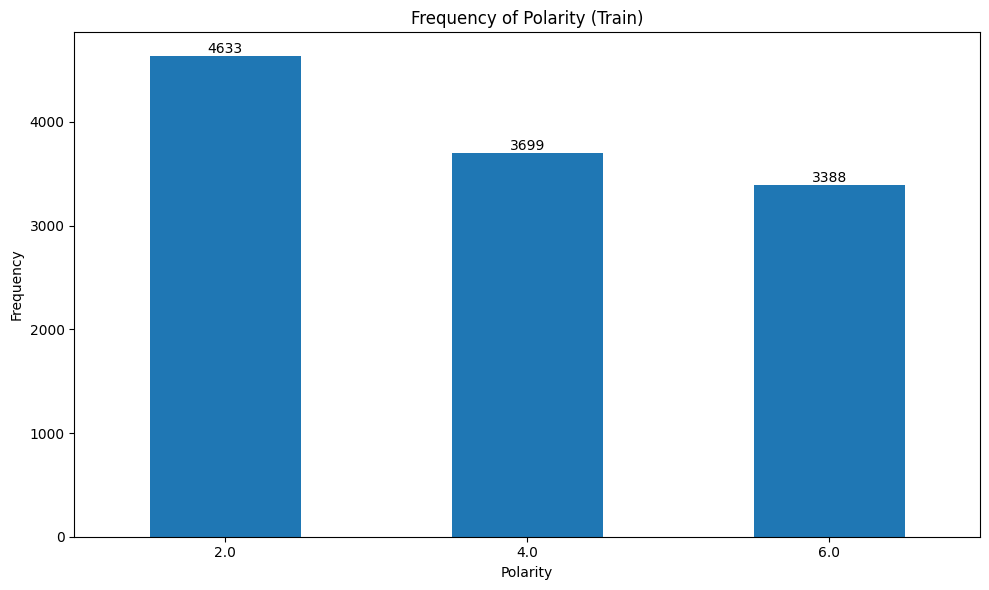

In [ ]:
# Observe distribution of labels
plt.figure(figsize=(10, 6))
ax = train['polarity'].value_counts().plot(kind='bar')
plt.title('Frequency of Polarity (Train)')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Show values as labels
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

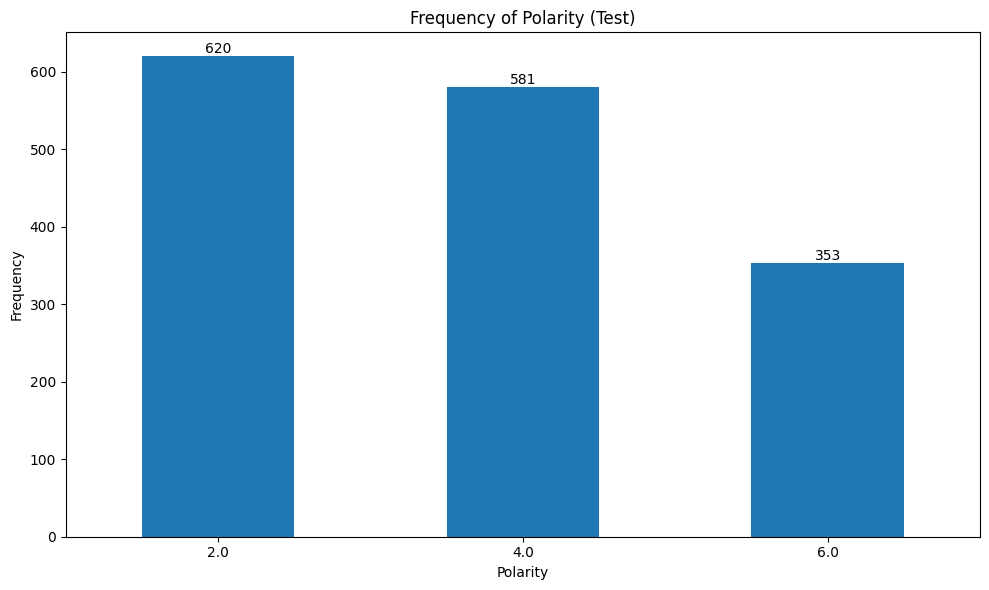

In [ ]:
# Observe distribution of labels
plt.figure(figsize=(10, 6))
ax = test['polarity'].value_counts().plot(kind='bar')
plt.title('Frequency of Polarity (Test)')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Show values as labels
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

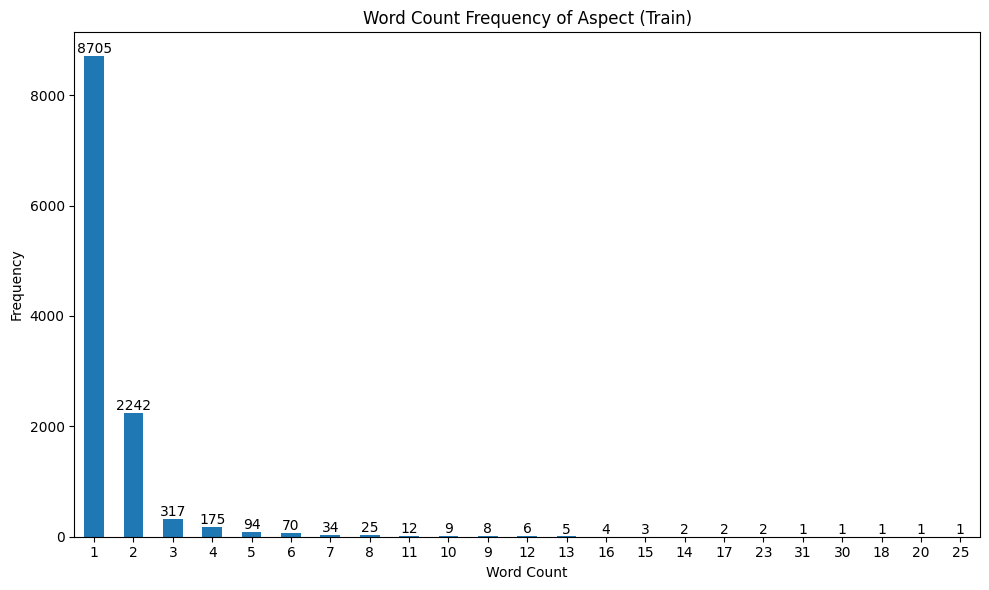

In [ ]:
# Word Count for apects
train['mention_word_count'] = train['mention'].apply(lambda x: len(x.split()))

# View frequency distribution
plt.figure(figsize=(10, 6))
ax = train['mention_word_count'].value_counts().plot(kind='bar')
plt.title('Word Count Frequency of Aspect (Train)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Show values as labels
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

## Paritioning

In [ ]:
names = ["sentence", "mention"]
X_train, X_val, y_train, y_val = train_test_split(train[names], train["polarity"], test_size=0.2)

In [ ]:
def combine_inputs(df_subset):
    return [f"{row['sentence']} </s> {row['mention']}" for _, row in df_subset.iterrows()]

train_sep = combine_inputs(X_train)
test_sep= combine_inputs(X_val)

label_map = {2: 0, 4: 1, 6: 2}

y_train = y_train.map(label_map).astype(int).tolist()
y_val = y_val.map(label_map).astype(int).tolist()

In [ ]:
test_x = test[names]
test_y = test["polarity"]

test_rw_x = combine_inputs(test_rw_x)
test_rw_y = test_y.map(label_map).astype(int).tolist()

## Dataset Class

In [ ]:
# Dataset class to encode text
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            return_tensors='pt'
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': int(self.labels[idx])
            }